# 🎵 Music Generation with AI — LSTM Deep Learning
### CPU-Friendly | Classical & Jazz MIDI | Full Pipeline

---
**What this notebook does:**
1. Downloads free MIDI music data (classical/jazz)
2. Preprocesses it into note sequences using `music21`
3. Builds an LSTM deep learning model
4. Trains the model to learn music patterns
5. Generates new music and saves it as a MIDI file

> ✅ CPU-only friendly — no GPU required!

## 📦 STEP 0 — Install Required Libraries
Run this cell **once**. After installation, you may need to restart the kernel.

In [1]:
# Install all required libraries
import sys

!{sys.executable} -m pip install music21 numpy tensorflow keras pretty_midi tqdm requests

print("\n✅ All libraries installed successfully!")
print("👉 If you see any errors above, restart the kernel and run this cell again.")

     ---------------------------------------- 0.0/5.6 MB ? eta -:--:--
     ---------------------------------------  5.5/5.6 MB 29.6 MB/s eta 0:00:01
     ---------------------------------------- 5.6/5.6 MB 28.0 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/20.1 MB ? eta -:--:--
   ----------- ---------------------------- 6.0/20.1 MB 28.8 MB/s eta 0:00:01
   ---------------------- ----------------- 11.5/20.1 MB 27.6 MB/s eta 0:00:01
   --------------------------------- ------ 17.0/20.1 MB 27.1 MB/s eta 0:00


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 📚 STEP 1 — Import Libraries

In [2]:
import os
import glob
import random
import pickle
import requests
import numpy as np
from tqdm import tqdm

# Music processing
from music21 import converter, instrument, note, chord, stream

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Activation
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Suppress TF warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

print(f"✅ TensorFlow version: {tf.__version__}")
print(f"✅ NumPy version: {np.__version__}")
print("✅ All imports successful! Let's make some music 🎹")

✅ TensorFlow version: 2.21.0
✅ NumPy version: 2.4.4
✅ All imports successful! Let's make some music 🎹


## 🎼 STEP 2 — Download Free MIDI Music Data

We download free classical MIDI files from public domain sources.

In [ ]:
# Create directory for MIDI files
os.makedirs("midi_data", exist_ok=True)
os.makedirs("output", exist_ok=True)

# ---------------------------------------------------------------
# Free public-domain MIDI files (Bach, Mozart, Beethoven)
# Source: various public domain MIDI repositories
# ---------------------------------------------------------------
MIDI_URLS = [
    # Bach - Well-Tempered Clavier (public domain)
    ("https://www.midiworld.com/download/4224", "bach_wtc_1.mid"),
    ("https://www.midiworld.com/download/4225", "bach_wtc_2.mid"),
    # Mozart - Piano Sonata
    ("https://www.midiworld.com/download/4440", "mozart_sonata.mid"),
    # Beethoven - Für Elise
    ("https://www.midiworld.com/download/482",  "beethoven_fur_elise.mid"),
]

downloaded = 0
for url, filename in MIDI_URLS:
    filepath = os.path.join("midi_data", filename)
    if os.path.exists(filepath):
        print(f"⏭️  Already exists: {filename}")
        downloaded += 1
        continue
    try:
        headers = {"User-Agent": "Mozilla/5.0"}
        r = requests.get(url, headers=headers, timeout=15)
        if r.status_code == 200 and len(r.content) > 500:
            with open(filepath, "wb") as f:
                f.write(r.content)
            print(f"✅ Downloaded: {filename}")
            downloaded += 1
        else:
            print(f"⚠️  Could not download {filename} (status {r.status_code})")
    except Exception as e:
        print(f"⚠️  Failed: {filename} — {e}")

print(f"\n📁 Total MIDI files ready: {downloaded}")

# ---------------------------------------------------------------
# FALLBACK: If downloads fail, we GENERATE synthetic MIDI data
# using music21 — this always works offline!
# ---------------------------------------------------------------
existing_midis = glob.glob("midi_data/*.mid")
if len(existing_midis) < 2:
    print("\n🔄 Generating synthetic training MIDI files...")
    
    def generate_synthetic_midi(filename, seed=42):
        """Generate a synthetic MIDI file with musical patterns."""
        random.seed(seed)
        np.random.seed(seed)
        
        # Musical scales: C major, G major, D minor, A minor
        scales = {
            "C_major": ["C4","D4","E4","F4","G4","A4","B4","C5",
                        "D5","E5","F5","G5","A5","B5","C3","D3","E3"],
            "G_major": ["G3","A3","B3","C4","D4","E4","F#4","G4",
                        "A4","B4","C5","D5","E5","F#5","G5"],
            "A_minor": ["A3","B3","C4","D4","E4","F4","G4","A4",
                        "B4","C5","D5","E5","F5","G5","A5"],
            "D_minor": ["D3","E3","F3","G3","A3","B-3","C4","D4",
                        "E4","F4","G4","A4","B-4","C5","D5"],
        }
        
        # Common chord progressions
        chord_progressions = [
            ["C4 E4 G4", "F4 A4 C5", "G4 B4 D5", "C4 E4 G4"],
            ["A3 C4 E4", "D4 F4 A4", "E4 G#4 B4", "A3 C4 E4"],
            ["G3 B3 D4", "C4 E4 G4", "D4 F#4 A4", "G3 B3 D4"],
        ]
        
        s = stream.Stream()
        piano = instrument.Piano()
        s.append(piano)
        
        scale_name = random.choice(list(scales.keys()))
        scale_notes = scales[scale_name]
        prog = random.choice(chord_progressions)
        
        durations = [0.5, 0.5, 1.0, 0.25, 0.25, 0.5, 1.0, 2.0]
        
        for measure in range(20):  # 20 measures
            # Melody notes
            for beat in range(8):
                if random.random() < 0.15:  # 15% chance of chord
                    chord_str = random.choice(prog)
                    chord_pitches = chord_str.split()
                    c = chord.Chord(chord_pitches)
                    c.duration.quarterLength = random.choice([0.5, 1.0])
                    s.append(c)
                elif random.random() < 0.1:  # 10% rest
                    r = note.Rest()
                    r.duration.quarterLength = random.choice([0.25, 0.5])
                    s.append(r)
                else:
                    n = note.Note(random.choice(scale_notes))
                    n.duration.quarterLength = random.choice(durations)
                    s.append(n)
        
        s.write("midi", fp=filename)
    
    for i in range(5):
        fname = f"midi_data/synthetic_{i+1}.mid"
        generate_synthetic_midi(fname, seed=i*7)
        print(f"  ✅ Created: {fname}")
    
    print("✅ Synthetic MIDI files generated!")

all_midis = glob.glob("midi_data/*.mid")
print(f"\n🎵 Total MIDI files available for training: {len(all_midis)}")
for m in all_midis:
    print(f"   📄 {m}")

⚠️  Could not download bach_wtc_1.mid (status 200)
⚠️  Could not download bach_wtc_2.mid (status 200)
⚠️  Could not download mozart_sonata.mid (status 200)
⚠️  Could not download beethoven_fur_elise.mid (status 200)

📁 Total MIDI files ready: 0

🎵 Total MIDI files available for training: 5
   📄 midi_data\synthetic_1.mid
   📄 midi_data\synthetic_2.mid
   📄 midi_data\synthetic_3.mid
   📄 midi_data\synthetic_4.mid
   📄 midi_data\synthetic_5.mid


## 🔧 STEP 3 — Parse & Preprocess MIDI Files

We extract notes and chords from MIDI files and convert them to sequences.

In [47]:
def extract_notes_from_midi(file_path):
    """Extract notes and chords from a MIDI file using music21."""
    notes_list = []
    try:
        midi_data = converter.parse(file_path)
        
        # Try to get notes from each instrument part
        parts = instrument.partitionByInstrument(midi_data)
        
        if parts:  # If there are separate instrument parts
            notes_to_parse = parts.parts[0].recurse()
        else:       # Otherwise use the flat note list
            notes_to_parse = midi_data.flat.notes
        
        for element in notes_to_parse:
            if isinstance(element, note.Note):
                # Single note → store its pitch as string e.g. "C4"
                notes_list.append(str(element.pitch))
            elif isinstance(element, chord.Chord):
                # Chord → store as dot-separated note numbers e.g. "60.64.67"
                notes_list.append(".".join(str(n) for n in element.normalOrder))
        
        return notes_list
    
    except Exception as e:
        print(f"  ⚠️  Skipping {file_path}: {e}")
        return []


# ── Extract notes from all MIDI files ──────────────────────────
print("🎵 Extracting notes from MIDI files...")
print("   (This may take a minute)\n")

all_notes = []
midi_files = glob.glob("midi_data/*.mid")

for midi_file in tqdm(midi_files, desc="Parsing MIDI"):
    extracted = extract_notes_from_midi(midi_file)
    all_notes.extend(extracted)
    print(f"  ✅ {os.path.basename(midi_file)}: {len(extracted)} notes/chords extracted")

print(f"\n📊 Total notes/chords extracted: {len(all_notes)}")
print(f"📊 Unique musical elements: {len(set(all_notes))}")
print(f"\n🔍 Sample (first 20 elements):")
print(all_notes[:20])

# Save for later use
with open("output/notes.pkl", "wb") as f:
    pickle.dump(all_notes, f)
print("\n💾 Notes saved to output/notes.pkl")

🎵 Extracting notes from MIDI files...
   (This may take a minute)



Parsing MIDI: 100%|██████████| 5/5 [00:00<00:00, 12.64it/s]

  ✅ synthetic_1.mid: 167 notes/chords extracted
  ✅ synthetic_2.mid: 161 notes/chords extracted
  ✅ synthetic_3.mid: 161 notes/chords extracted
  ✅ synthetic_4.mid: 161 notes/chords extracted
  ✅ synthetic_5.mid: 180 notes/chords extracted

📊 Total notes/chords extracted: 830
📊 Unique musical elements: 32

🔍 Sample (first 20 elements):
['9.0.4', 'D4', 'E4', 'F4', 'A4', 'D5', 'D5', 'C4', 'E4', 'D3', '9.0.4', 'B-3', 'E3', 'B-4', 'E3', 'D4', 'E3', 'B-4', 'C4', 'G3']

💾 Notes saved to output/notes.pkl


## 🔢 STEP 4 — Prepare Training Sequences

Convert note strings → numbers, then create input/output pairs for the LSTM.

In [5]:
# ── Parameters (CPU-friendly settings) ─────────────────────────
SEQUENCE_LENGTH = 50    # How many notes to look back
MIN_NOTE_FREQ   = 1     # Minimum times a note must appear

# ── Filter rare notes ───────────────────────────────────────────
from collections import Counter
note_counts = Counter(all_notes)
all_notes_filtered = [n for n in all_notes if note_counts[n] >= MIN_NOTE_FREQ]

# ── Create vocabulary ───────────────────────────────────────────
unique_notes = sorted(set(all_notes_filtered))
n_vocab = len(unique_notes)

print(f"📚 Vocabulary size (unique notes/chords): {n_vocab}")

# ── Mappings: note ↔ integer ────────────────────────────────────
note_to_int = {n: i for i, n in enumerate(unique_notes)}
int_to_note = {i: n for i, n in enumerate(unique_notes)}

# Save mappings
with open("output/note_to_int.pkl", "wb") as f:
    pickle.dump(note_to_int, f)
with open("output/int_to_note.pkl", "wb") as f:
    pickle.dump(int_to_note, f)

# ── Build input/output sequences ────────────────────────────────
X_sequences = []
y_targets   = []

for i in range(len(all_notes_filtered) - SEQUENCE_LENGTH):
    seq_in  = all_notes_filtered[i : i + SEQUENCE_LENGTH]
    seq_out = all_notes_filtered[i + SEQUENCE_LENGTH]
    X_sequences.append([note_to_int[n] for n in seq_in])
    y_targets.append(note_to_int[seq_out])

n_patterns = len(X_sequences)
print(f"🔢 Total training patterns: {n_patterns}")

# ── Reshape for LSTM: (samples, timesteps, features) ────────────
X = np.reshape(X_sequences, (n_patterns, SEQUENCE_LENGTH, 1))
X = X / float(n_vocab)          # Normalize to [0, 1]
y = to_categorical(y_targets)   # One-hot encode outputs

print(f"\n✅ X shape: {X.shape}  →  (samples, timesteps, features)")
print(f"✅ y shape: {y.shape}  →  (samples, n_vocab)")
print("\n🎯 Data is ready for training!")

📚 Vocabulary size (unique notes/chords): 32
🔢 Total training patterns: 780

✅ X shape: (780, 50, 1)  →  (samples, timesteps, features)
✅ y shape: (780, 32)  →  (samples, n_vocab)

🎯 Data is ready for training!


## 🧠 STEP 5 — Build the LSTM Model

A stacked LSTM architecture to learn music patterns.

In [48]:
def build_model(sequence_length, n_vocab):
    """
    Build a stacked LSTM model for music generation.
    CPU-friendly: smaller hidden sizes, fewer layers.
    """
    model = Sequential([
        # Layer 1 — LSTM (returns sequences for stacking)
        LSTM(
            256,
            input_shape=(sequence_length, 1),
            return_sequences=True
        ),
        Dropout(0.3),
        
        # Layer 2 — LSTM (returns sequences)
        LSTM(256, return_sequences=True),
        Dropout(0.3),
        
        # Layer 3 — LSTM (final, no sequence return)
        LSTM(128),
        Dropout(0.3),
        
        # Fully connected output
        Dense(n_vocab),
        Activation("softmax")  # Probability over each possible note
    ])
    
    model.compile(
        loss="categorical_crossentropy",
        optimizer="adam"
    )
    
    return model


# Build the model
model = build_model(SEQUENCE_LENGTH, n_vocab)

print("🧠 Model Architecture:")
print("=" * 55)
model.summary()
print("=" * 55)
print("✅ Model built successfully!")

c:\Users\shant\OneDrive\Desktop\CodeAlpha\music_ai_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


🧠 Model Architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 50, 256)        │       264,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 50, 256)        │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 50, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 990,752 (3.78 MB)

 Trainable params: 990,752 (3.78 MB)

 Non-trainable params: 0 (0.00 B)

✅ Model built successfully!


## 🏋️ STEP 6 — Train the Model

> ⚠️ **CPU Training Note:**  
> Training takes time on CPU. We use **20 epochs** with early stopping.  
> You'll see loss decrease — that means the model is learning! 🎉

In [49]:
os.makedirs("output/checkpoints", exist_ok=True)

# ── Callbacks ──────────────────────────────────────────────────
checkpoint_cb = ModelCheckpoint(
    filepath="output/checkpoints/best_model.keras",
    monitor="loss",
    save_best_only=True,
    verbose=1
)

earlystop_cb = EarlyStopping(
    monitor="loss",
    patience=5,          # Stop if no improvement for 5 epochs
    restore_best_weights=True,
    verbose=1
)

# ── Training ────────────────────────────────────────────────────
print("🏋️  Starting training...")
print("   (Each epoch may take 1–5 min on CPU — be patient!)")
print("   Watch the 'loss' decrease — lower = better learning!\n")

EPOCHS     = 20   # Reduce to 5 for a quick test
BATCH_SIZE = 64   # Larger batch = faster but more memory

history = model.fit(
    X, y,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[checkpoint_cb, earlystop_cb],
    verbose=1
)

# Save final model too
model.save("output/music_model_final.keras")

print("\n✅ Training complete!")
print(f"   Best loss: {min(history.history['loss']):.4f}")
print("   Model saved to output/music_model_final.keras")

🏋️  Starting training...
   (Each epoch may take 1–5 min on CPU — be patient!)
   Watch the 'loss' decrease — lower = better learning!

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - loss: 3.4346
Epoch 1: loss improved from None to 3.41972, saving model to output/checkpoints/best_model.keras

Epoch 1: finished saving model to output/checkpoints/best_model.keras
13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 448ms/step - loss: 3.4197
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - loss: 3.3883
Epoch 2: loss improved from 3.41972 to 3.37527, saving model to output/checkpoints/best_model.keras

Epoch 2: finished saving model to output/checkpoints/best_model.keras
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 462ms/step - loss: 3.3753
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - loss: 3.3594
Epoch 3: loss improved from 3.37527 to 3.34416, saving model to output/checkpoints/best_model.keras

Epoch 3: finished saving model to output/checkpoints/best_model.keras
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 427ms/step

## 📈 STEP 7 — Visualize Training Loss

C:\Users\shant\AppData\Local\Temp\ipykernel_22268\4262489613.py:30: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\shant\AppData\Local\Temp\ipykernel_22268\4262489613.py:31: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  plt.savefig("output/training_loss.png", dpi=150)
c:\Users\shant\OneDrive\Desktop\CodeAlpha\music_ai_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


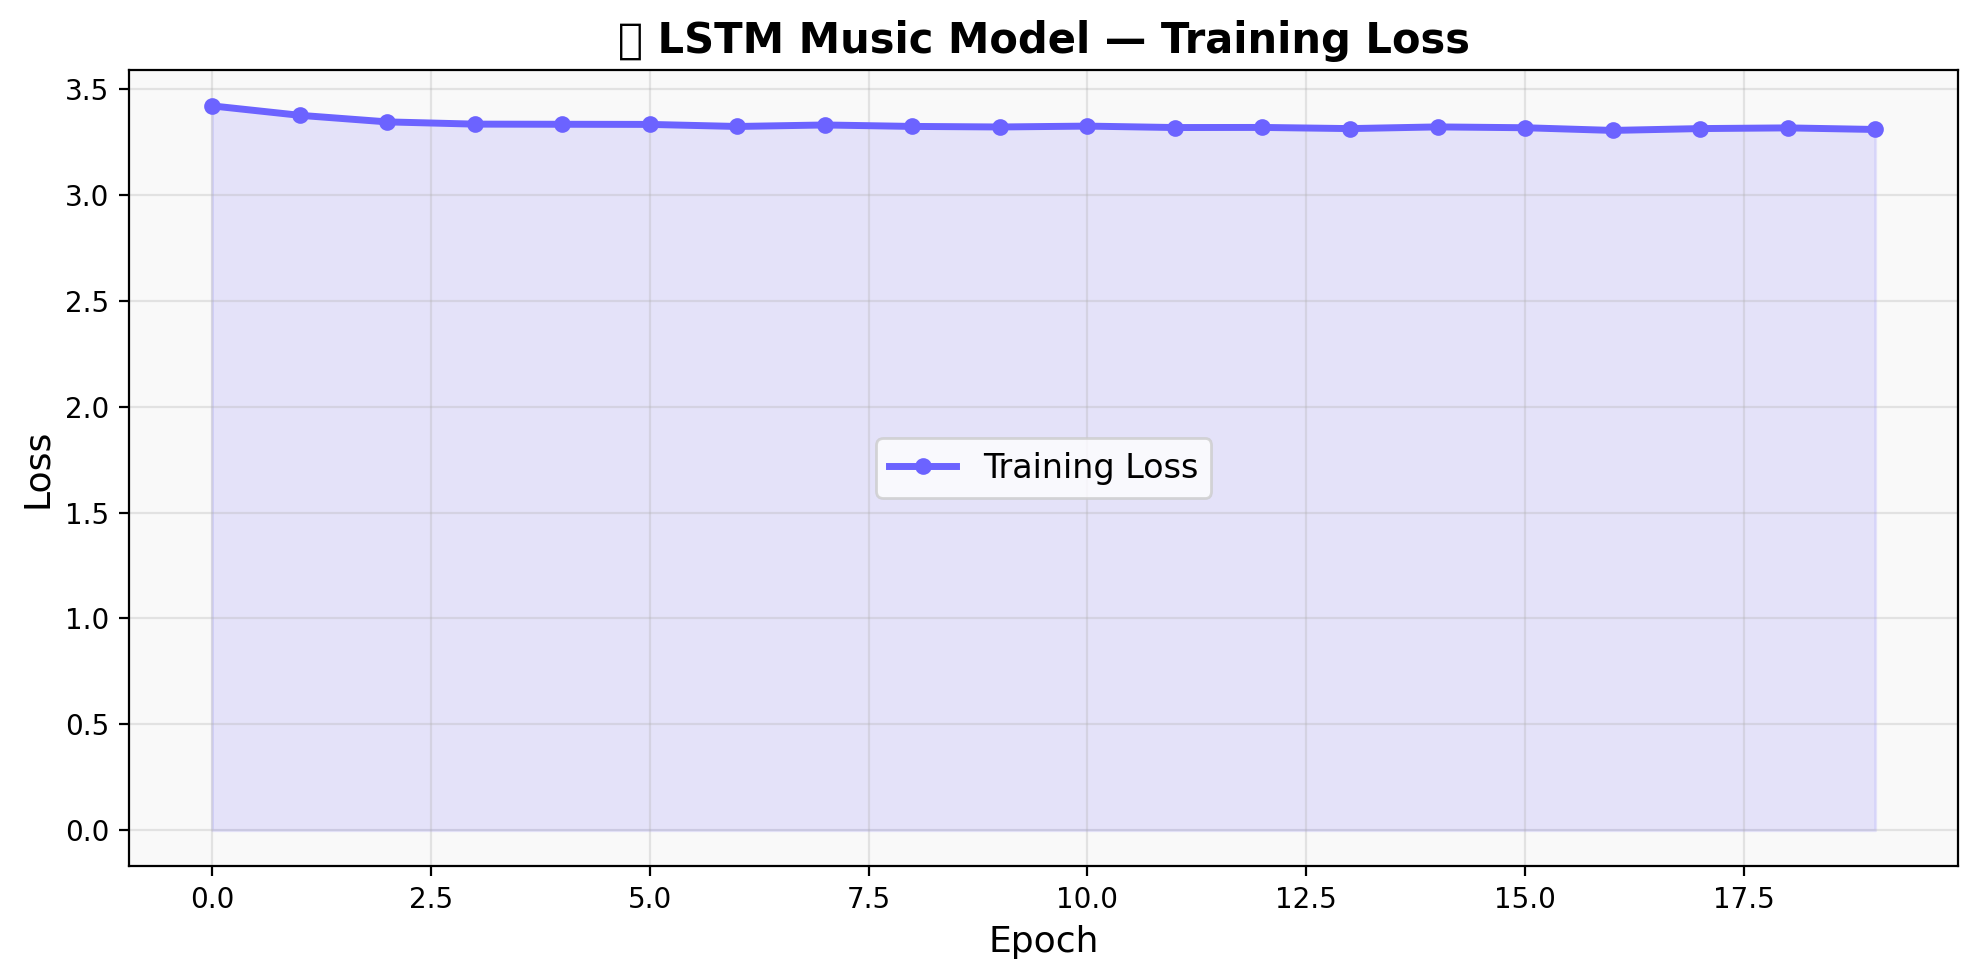

📊 Loss chart saved to output/training_loss.png


In [50]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    history.history["loss"],
    color="#6C63FF",
    linewidth=2.5,
    marker="o",
    markersize=5,
    label="Training Loss"
)

ax.fill_between(
    range(len(history.history["loss"])),
    history.history["loss"],
    alpha=0.15,
    color="#6C63FF"
)

ax.set_xlabel("Epoch", fontsize=13)
ax.set_ylabel("Loss", fontsize=13)
ax.set_title("🎵 LSTM Music Model — Training Loss", fontsize=15, fontweight="bold")
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_facecolor("#f9f9f9")
fig.patch.set_facecolor("white")

plt.tight_layout()
plt.savefig("output/training_loss.png", dpi=150)
plt.show()
print("📊 Loss chart saved to output/training_loss.png")

## 🎼 STEP 8 — Generate New Music!

The trained model generates a new sequence of notes from a random seed.

In [51]:
def generate_notes(model, int_to_note, note_to_int, all_notes_filtered,
                   n_vocab, sequence_length=50, num_generate=200, temperature=1.0):
    """
    Generate a sequence of notes using the trained model.
    
    temperature: controls creativity
        < 1.0 → more predictable / safe
        = 1.0 → balanced
        > 1.0 → more random / creative
    """
    # Pick a random starting seed from training data
    start_idx = random.randint(0, len(all_notes_filtered) - sequence_length - 1)
    seed_sequence = all_notes_filtered[start_idx : start_idx + sequence_length]
    
    # Convert seed to integers
    pattern = [note_to_int[n] for n in seed_sequence]
    generated_notes = []
    
    print(f"🎲 Seed starts with: {seed_sequence[:5]}...")
    print(f"🎶 Generating {num_generate} notes/chords...")
    
    for _ in tqdm(range(num_generate), desc="Generating"):
        # Reshape for prediction
        x = np.reshape(pattern, (1, sequence_length, 1))
        x = x / float(n_vocab)
        
        # Predict next note probabilities
        prediction = model.predict(x, verbose=0)[0]
        
        # Apply temperature scaling
        prediction = np.log(prediction + 1e-10) / temperature
        prediction = np.exp(prediction)
        prediction = prediction / prediction.sum()
        
        # Sample from the distribution
        next_index = np.random.choice(len(prediction), p=prediction)
        next_note  = int_to_note[next_index]
        
        generated_notes.append(next_note)
        
        # Slide the window forward
        pattern.append(next_index)
        pattern = pattern[1:]
    
    print(f"\n✅ Generated {len(generated_notes)} notes!")
    print(f"🔍 Sample: {generated_notes[:10]}")
    return generated_notes


# ── Generate! ────────────────────────────────────────────────────
# Load the best saved model
try:
    best_model = load_model("output/checkpoints/best_model.keras")
    print("✅ Loaded best checkpoint model")
except:
    best_model = model
    print("✅ Using current trained model")

generated_notes = generate_notes(
    model            = best_model,
    int_to_note      = int_to_note,
    note_to_int      = note_to_int,
    all_notes_filtered = all_notes_filtered,
    n_vocab          = n_vocab,
    sequence_length  = SEQUENCE_LENGTH,
    num_generate     = 150,   # Number of notes to generate
    temperature      = 0.8    # Lower = more musical, Higher = more random
)

✅ Loaded best checkpoint model
🎲 Seed starts with: ['C5', '7.11.2', 'A5', 'F4', 'E5']...
🎶 Generating 150 notes/chords...


Generating: 100%|██████████| 150/150 [00:18<00:00,  8.05it/s]


✅ Generated 150 notes!
🔍 Sample: ['7.11.2', 'F5', 'B4', '0.4.7', 'G5', 'G4', '4.8.11', 'F4', 'A4', 'C5']


## 💾 STEP 9 — Convert to MIDI and Save

Convert the generated note list back into a playable MIDI file.

In [52]:
def notes_to_midi(generated_notes, output_path, instrument_name="Piano"):
    """
    Convert a list of note/chord strings back into a MIDI file.
    """
    output_notes = []
    offset = 0  # Time position in the piece
    
    for pattern in generated_notes:
        # Is it a chord? (contains ".")
        if "." in pattern:
            chord_notes_list = pattern.split(".")
            notes_in_chord = []
            for current_note in chord_notes_list:
                try:
                    new_note = note.Note(int(current_note))
                    new_note.storedInstrument = instrument.Piano()
                    notes_in_chord.append(new_note)
                except:
                    pass
            if notes_in_chord:
                new_chord = chord.Chord(notes_in_chord)
                new_chord.offset = offset
                output_notes.append(new_chord)
        
        # Is it a rest?
        elif pattern == "R" or pattern == "rest":
            new_note = note.Rest()
            new_note.offset = offset
            output_notes.append(new_note)
        
        # It's a single note
        else:
            try:
                new_note = note.Note(pattern)
                new_note.offset = offset
                new_note.storedInstrument = instrument.Piano()
                output_notes.append(new_note)
            except:
                pass
        
        # Advance time (vary rhythm slightly for musicality)
        offset += random.choice([0.5, 0.5, 0.5, 1.0, 0.25])
    
    # Build and save the stream
    midi_stream = stream.Stream(output_notes)
    midi_stream.write("midi", fp=output_path)
    print(f"💾 MIDI saved to: {output_path}")
    return output_path


# ── Save the generated music ─────────────────────────────────────
output_midi_path = "output/generated_music.mid"

notes_to_midi(
    generated_notes = generated_notes,
    output_path     = output_midi_path
)

print("\n🎉 Your AI-composed music has been saved!")
print(f"   📁 Location: {os.path.abspath(output_midi_path)}")

💾 MIDI saved to: output/generated_music.mid

🎉 Your AI-composed music has been saved!
   📁 Location: c:\Users\shant\OneDrive\Desktop\CodeAlpha\output\generated_music.mid


## 🎧 STEP 10 — Visualize the Generated Music

Show a piano-roll style chart of the generated notes.

C:\Users\shant\AppData\Local\Temp\ipykernel_22268\4184087751.py:66: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\shant\AppData\Local\Temp\ipykernel_22268\4184087751.py:67: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  plt.savefig("output/piano_roll.png", dpi=150, bbox_inches="tight")


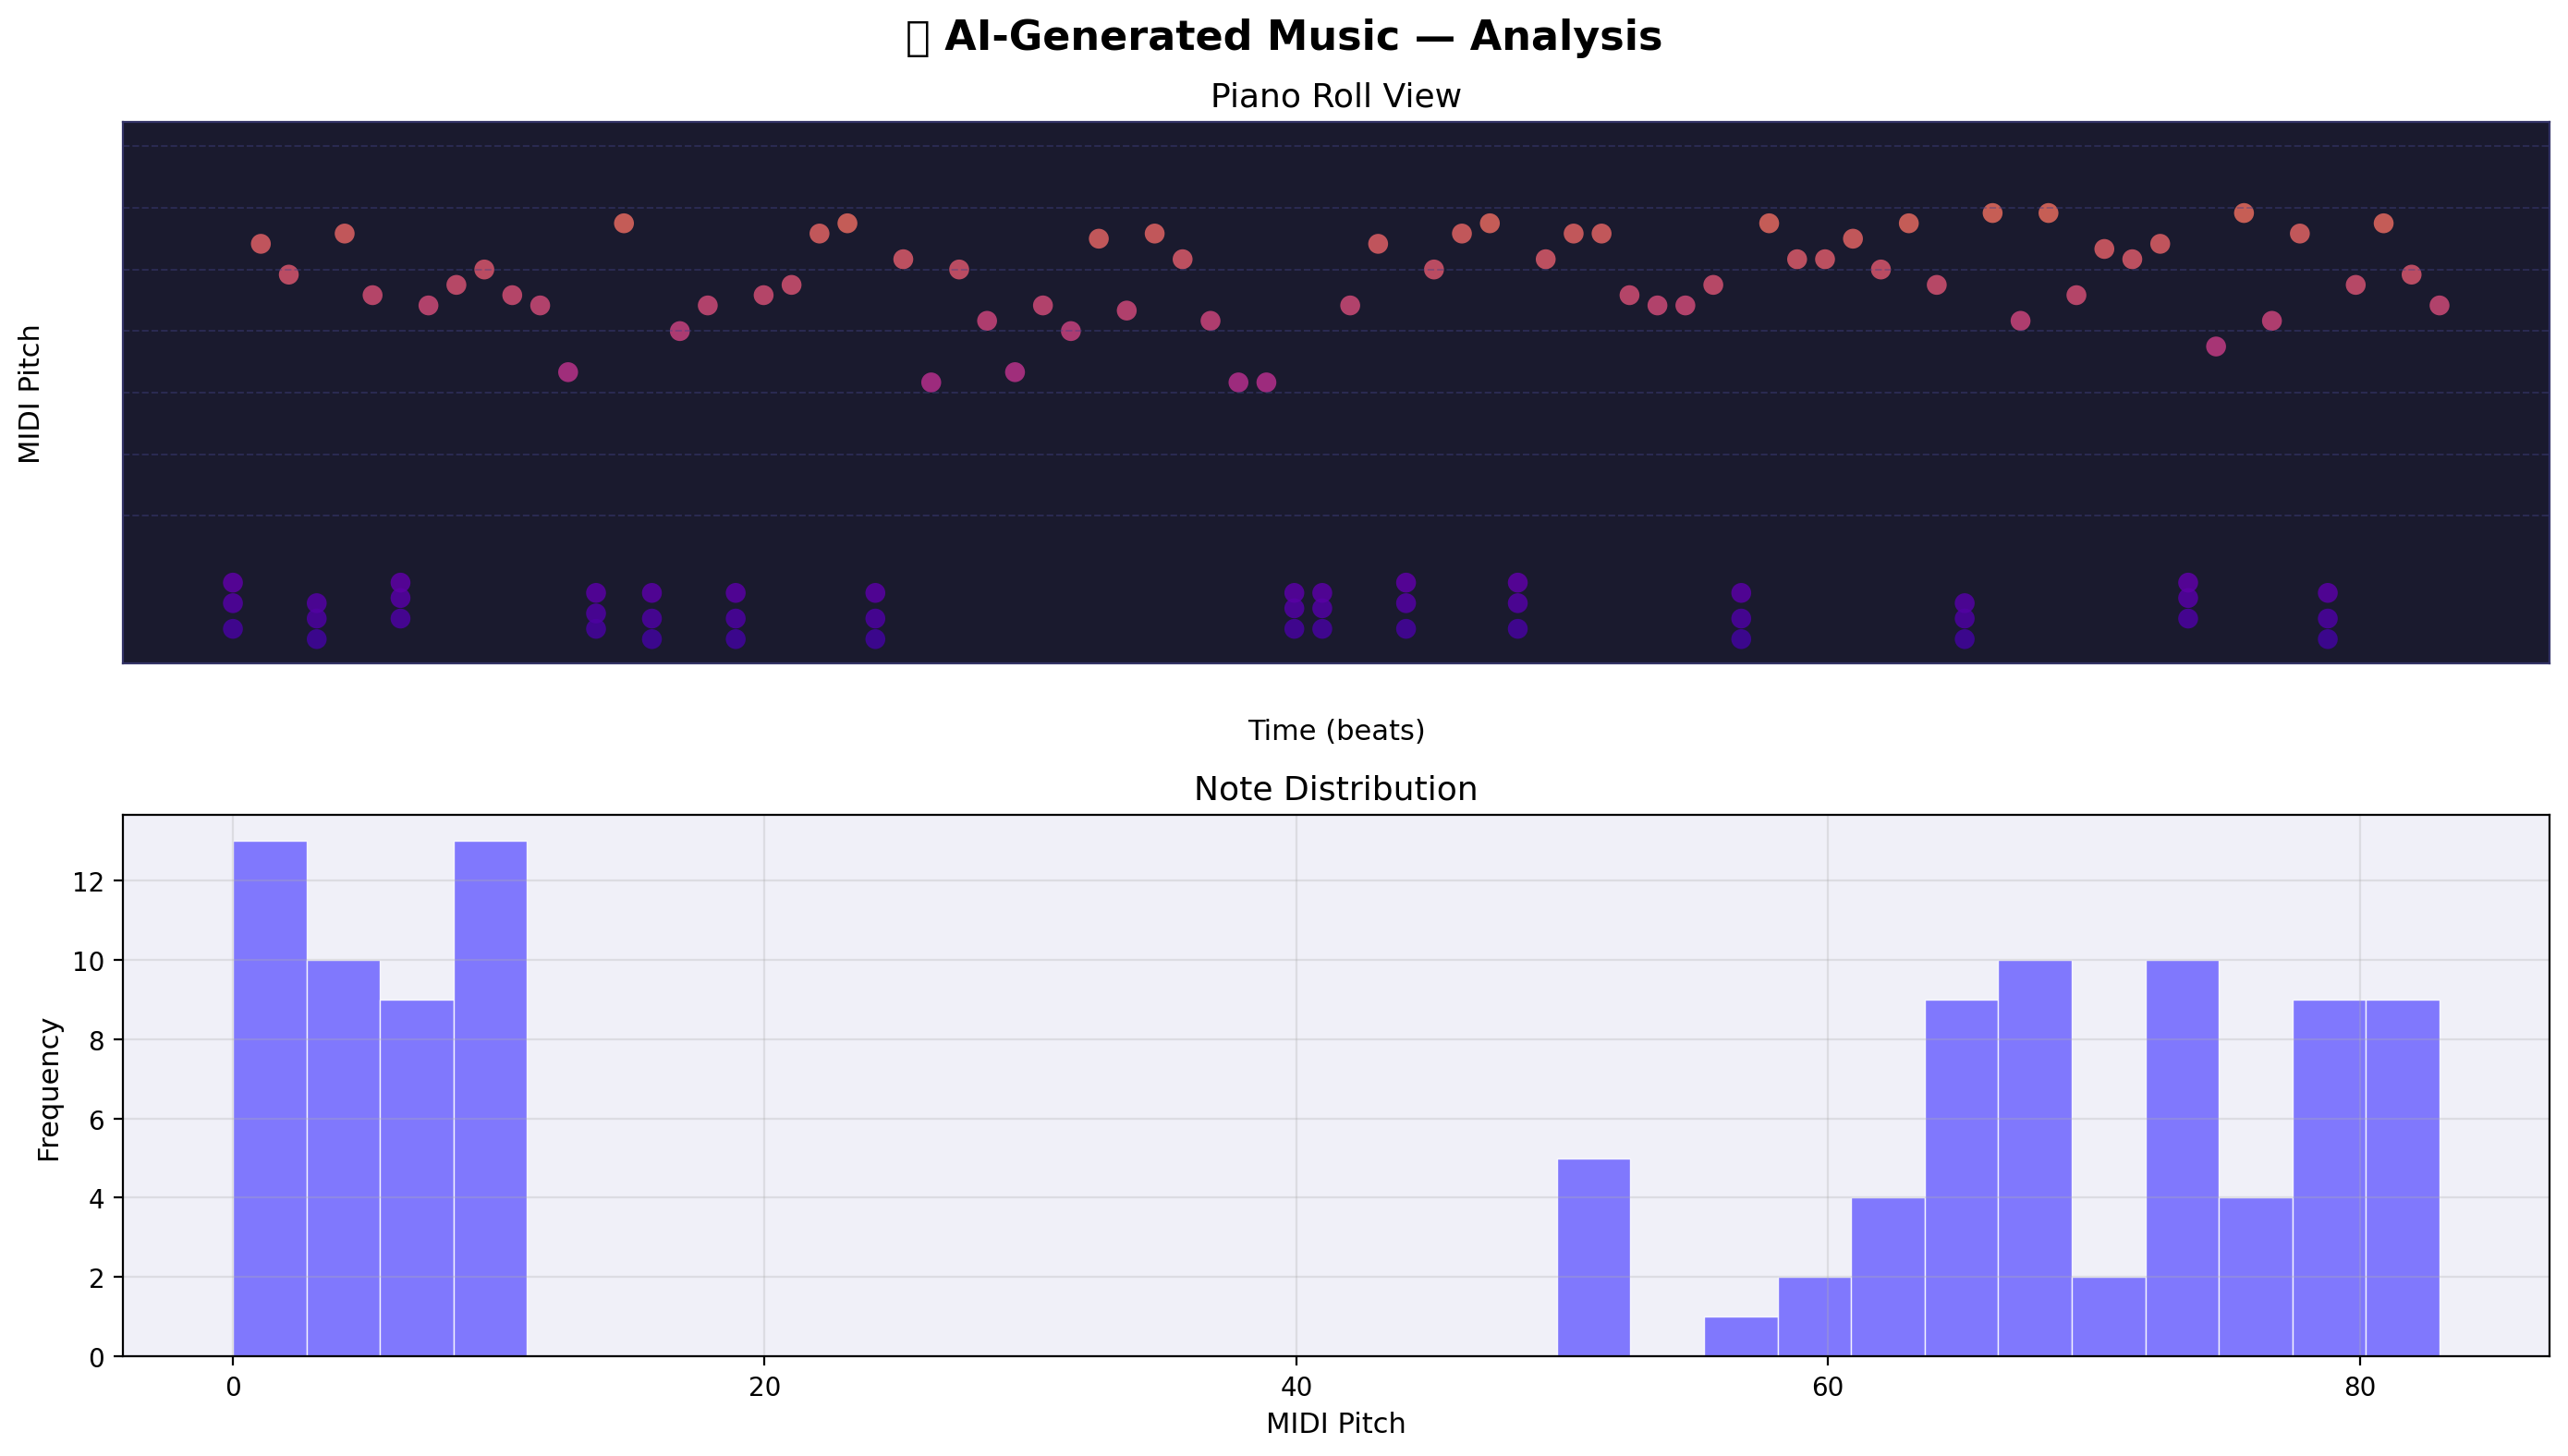

🖼️  Piano roll saved to output/piano_roll.png


In [53]:
def visualize_generated_notes(generated_notes, max_display=80):
    """Draw a piano-roll style visualization of generated notes."""
    
    # Collect pitches and timestamps
    pitches = []
    times   = []
    colors  = []
    offset  = 0
    
    pitch_map = {}
    color_palette = plt.cm.plasma(np.linspace(0.1, 0.9, 128))
    
    for i, pattern in enumerate(generated_notes[:max_display]):
        if "." in pattern:  # Chord
            for p in pattern.split("."):
                try:
                    pitch_val = int(p)
                    pitches.append(pitch_val)
                    times.append(offset)
                    colors.append(color_palette[min(pitch_val, 127)])
                except:
                    pass
        else:               # Single note
            try:
                n_obj = note.Note(pattern)
                midi_num = n_obj.pitch.midi
                pitches.append(midi_num)
                times.append(offset)
                colors.append(color_palette[min(midi_num, 127)])
            except:
                pass
        offset += 0.5
    
    if not pitches:
        print("⚠️  Could not parse notes for visualization.")
        return
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    fig.suptitle("🎵 AI-Generated Music — Analysis", fontsize=16, fontweight="bold")
    
    # ── Piano Roll ──────────────────────────────────────────────
    ax1 = axes[0]
    ax1.scatter(times, pitches, c=colors, s=60, alpha=0.85, edgecolors="none")
    ax1.set_xlabel("Time (beats)", fontsize=11)
    ax1.set_ylabel("MIDI Pitch", fontsize=11)
    ax1.set_title("Piano Roll View", fontsize=13)
    ax1.set_facecolor("#1a1a2e")
    ax1.tick_params(colors="white")
    ax1.spines[:].set_color("#333366")
    ax1.yaxis.label.set_color("black")
    ax1.xaxis.label.set_color("black")
    
    # Add octave lines
    for octave_pitch in range(24, 108, 12):
        ax1.axhline(y=octave_pitch, color="#444488", linestyle="--", alpha=0.4, linewidth=0.7)
    
    # ── Pitch Histogram ─────────────────────────────────────────
    ax2 = axes[1]
    ax2.hist(pitches, bins=30, color="#6C63FF", edgecolor="white", linewidth=0.5, alpha=0.85)
    ax2.set_xlabel("MIDI Pitch", fontsize=11)
    ax2.set_ylabel("Frequency", fontsize=11)
    ax2.set_title("Note Distribution", fontsize=13)
    ax2.set_facecolor("#f0f0f8")
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig("output/piano_roll.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("🖼️  Piano roll saved to output/piano_roll.png")


visualize_generated_notes(generated_notes)

## 🔊 STEP 11 — Play the MIDI (Optional)

You can play the generated MIDI using:
- **Windows:** VLC, Windows Media Player, or GarageBand
- **Mac:** GarageBand, QuickTime
- **Online:** [MIDI.js Soundfont Player](https://gleitz.github.io/midi-js-soundfonts/) or [OnlineSequencer.net](https://onlinesequencer.net/import)

The cell below tries to use `pygame` to play directly in the notebook.

In [54]:
import subprocess
import sys

# Install required libraries
subprocess.check_call([sys.executable, "-m", "pip", "install", "midi2audio", "-q"])

try:
    # Try using FluidSynth (needs separate install)
    from midi2audio import FluidSynth
    fs = FluidSynth()
    fs.midi_to_audio("output/generated_music.mid", "output/generated_music.wav")
    print("✅ Converted to WAV!")

except Exception:
    # Fallback: use pygame
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pygame", "-q"])
    import pygame, time
    pygame.mixer.init()
    pygame.mixer.music.load("output/generated_music.mid")
    pygame.mixer.music.play()
    print("🎵 Playing... (wait for it)")
    while pygame.mixer.music.get_busy():
        time.sleep(1)
    print("✅ Done!")

🎵 Playing... (wait for it)
✅ Done!


---
## 🚀 Bonus — Generate Multiple Variations

Run this cell to generate 3 different pieces with different creativity levels!

In [44]:
variations = [
    ("conservative", 0.5),   # Safe, predictable
    ("balanced",     0.9),   # Default
    ("creative",     1.3),   # More experimental
]

for name, temp in variations:
    print(f"\n🎵 Generating '{name}' variation (temperature={temp})...")
    notes_var = generate_notes(
        model=best_model,
        int_to_note=int_to_note,
        note_to_int=note_to_int,
        all_notes_filtered=all_notes_filtered,
        n_vocab=n_vocab,
        sequence_length=SEQUENCE_LENGTH,
        num_generate=100,
        temperature=temp
    )
    out_path = f"output/generated_{name}.mid"
    notes_to_midi(notes_var, out_path)

print("\n✅ All 3 variations saved to the output/ folder!")
print("   Try opening them in VLC or any MIDI player.")


🎵 Generating 'conservative' variation (temperature=0.5)...
🎲 Seed starts with: ['2.6.9', 'B4', '7.11.2', 'D5', 'D5']...
🎶 Generating 100 notes/chords...


Generating: 100%|██████████| 100/100 [00:14<00:00,  6.78it/s]



✅ Generated 100 notes!
🔍 Sample: ['9.0.4', 'A4', 'D4', 'B5', 'D5', 'F4', 'C4', 'C4', 'B4', 'B4']
💾 MIDI saved to: output/generated_conservative.mid

🎵 Generating 'balanced' variation (temperature=0.9)...
🎲 Seed starts with: ['7.11.2', 'A4', 'D4', 'C5', 'C5']...
🎶 Generating 100 notes/chords...


Generating: 100%|██████████| 100/100 [00:11<00:00,  8.67it/s]



✅ Generated 100 notes!
🔍 Sample: ['F4', 'D5', '2.5.9', '9.0.4', 'A4', 'C3', 'C4', '5.9.0', '2.5.9', 'F4']
💾 MIDI saved to: output/generated_balanced.mid

🎵 Generating 'creative' variation (temperature=1.3)...
🎲 Seed starts with: ['E4', '0.4.7', 'A4', '0.4.7', 'A4']...
🎶 Generating 100 notes/chords...


Generating: 100%|██████████| 100/100 [00:12<00:00,  7.92it/s]



✅ Generated 100 notes!
🔍 Sample: ['D5', 'E3', 'A4', 'F#4', 'G3', 'D3', 'D3', '0.4.7', '9.0.4', 'A5']
💾 MIDI saved to: output/generated_creative.mid

✅ All 3 variations saved to the output/ folder!
   Try opening them in VLC or any MIDI player.


In [45]:
import subprocess
import sys
import os

# Install pygame
subprocess.check_call([sys.executable, "-m", "pip", "install", "pygame", "-q"])

import pygame
import time
from IPython.display import display, Audio, HTML

def play_midi(filepath, label=""):
    """Play a MIDI file using pygame."""
    print(f"\n🎵 Playing: {label} ({filepath})")
    try:
        pygame.mixer.init(frequency=44100, size=-16, channels=2, buffer=512)
        pygame.mixer.music.load(filepath)
        pygame.mixer.music.play()
        
        duration = 0
        while pygame.mixer.music.get_busy():
            time.sleep(0.5)
            duration += 0.5
            if duration > 60:  # Max 60 seconds per file
                break
        
        pygame.mixer.music.stop()
        print(f"   ✅ Done playing: {label}")
    
    except Exception as e:
        print(f"   ⚠️  Could not play {label}: {e}")
    
    finally:
        pygame.mixer.quit()

# ── Play all 3 variations one by one ───────────────────────────
midi_files = [
    ("output/generated_conservative.mid", "🎯 Conservative"),
    ("output/generated_balanced.mid",     "⚖️  Balanced"),
    ("output/generated_creative.mid",     "🎨 Creative"),
]

print("=" * 50)
print("   🎹 AI Music Player — 3 Variations")
print("=" * 50)

for filepath, label in midi_files:
    if os.path.exists(filepath):
        play_midi(filepath, label)
        time.sleep(1)  # Small gap between songs
    else:
        print(f"⚠️  File not found: {filepath}")

print("\n🎉 All variations played!")

   🎹 AI Music Player — 3 Variations

🎵 Playing: 🎯 Conservative (output/generated_conservative.mid)
   ✅ Done playing: 🎯 Conservative

🎵 Playing: ⚖️  Balanced (output/generated_balanced.mid)
   ✅ Done playing: ⚖️  Balanced

🎵 Playing: 🎨 Creative (output/generated_creative.mid)
   ✅ Done playing: 🎨 Creative

🎉 All variations played!


In [43]:
# ============================================================
# 🎸 INSTRUMENT CHANGER — Only change the ONE line below!
# ============================================================

# 👇 CHANGE ONLY THIS LINE to switch instrument:
MY_INSTRUMENT = "Guitar"   # ← Change this word!

# ── Available options (copy-paste any one above) ──────────
# "Piano"     "Guitar"     "ElectricGuitar"    "Violin"
# "Trumpet"   "Saxophone"  "Flute"             "Clarinet"
# "Harp"      "Cello"
# ----------------------------------------------------------

instrument_map = {
    "Piano"         : (instrument.Piano(),         0),
    "Guitar"        : (instrument.Guitar(),        25),
    "ElectricGuitar": (instrument.ElectricGuitar(),27),
    "Violin"        : (instrument.Violin(),        40),
    "Trumpet"       : (instrument.Trumpet(),       56),
    "Saxophone"     : (instrument.Saxophone(),     65),
    "Flute"         : (instrument.Flute(),         73),
    "Clarinet"      : (instrument.Clarinet(),      71),
    "Harp"          : (instrument.Harp(),          46),
    "Cello"         : (instrument.Violoncello(),   42),
}

def notes_to_midi_instrument(generated_notes, output_path, chosen_instrument):
    output_notes = []
    offset = 0

    selected_instrument, program_num = instrument_map.get(
        chosen_instrument, instrument_map["Piano"]
    )
    selected_instrument.midiProgram = program_num

    for pattern in generated_notes:
        if "." in pattern:
            notes_in_chord = []
            for current_note in pattern.split("."):
                try:
                    notes_in_chord.append(note.Note(int(current_note)))
                except:
                    pass
            if notes_in_chord:
                new_chord = chord.Chord(notes_in_chord)
                new_chord.offset = offset
                output_notes.append(new_chord)

        elif pattern in ("R", "rest"):
            r = note.Rest()
            r.offset = offset
            output_notes.append(r)

        else:
            try:
                n = note.Note(pattern)
                n.offset = offset
                output_notes.append(n)
            except:
                pass

        offset += random.choice([0.5, 0.5, 0.5, 1.0, 0.25])

    midi_part = stream.Part()
    midi_part.insert(0, selected_instrument)
    for n in output_notes:
        midi_part.append(n)

    final_stream = stream.Score()
    final_stream.append(midi_part)
    final_stream.write("midi", fp=output_path)

    print(f"✅ Saved!  Instrument → {chosen_instrument}  (Program #{program_num})")
    print(f"📁 File   → {os.path.abspath(output_path)}")
    return output_path

# ── Generate & Save ────────────────────────────────────────
out_path = f"output/generated_{MY_INSTRUMENT.lower()}.mid"
notes_to_midi_instrument(generated_notes, out_path, MY_INSTRUMENT)

# ── Play it immediately ────────────────────────────────────
import pygame, time
pygame.mixer.init(frequency=44100, size=-16, channels=2, buffer=512)
pygame.mixer.music.load(out_path)
pygame.mixer.music.play()
print(f"\n🎵 Playing {MY_INSTRUMENT} music...")
while pygame.mixer.music.get_busy():
    time.sleep(0.5)
pygame.mixer.quit()
print("🎉 Done!")

✅ Saved!  Instrument → Guitar  (Program #25)
📁 File   → c:\Users\shant\OneDrive\Desktop\CodeAlpha\output\generated_guitar.mid

🎵 Playing Guitar music...
🎉 Done!
